In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install --upgrade tensorflow


In [ ]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import Conv2D, Dense, BatchNormalization, Activation, Dropout, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, TensorBoard, EarlyStopping, ReduceLROnPlateau
import datetime
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model


In [ ]:
train_dir = '/content/drive/MyDrive/MERK/Datasets/dataface/train/'
test_dir = '/content/drive/MyDrive/MERK/Datasets/dataface/test/'

row, col = 48, 48
classes = 7

def count_exp(path, set_):
    dict_ = {}
    for expression in os.listdir(path):
        dir_ = path + expression
        dict_[expression] = len(os.listdir(dir_))
    df = pd.DataFrame(dict_, index=[set_])
    return df
train_count = count_exp(train_dir, 'train')
test_count = count_exp(test_dir, 'test')
print(train_count)
print(test_count)

       surprise  fear   sad  happy  disgust  neutral  angry
train      3171  4097  4836   7215      436     4975   3995
       sad  surprise  neutral  fear  disgust  angry  happy
test  1247       831     1233  1024      111    958   1774


Plot Number Of Images in Training Set

<Axes: >

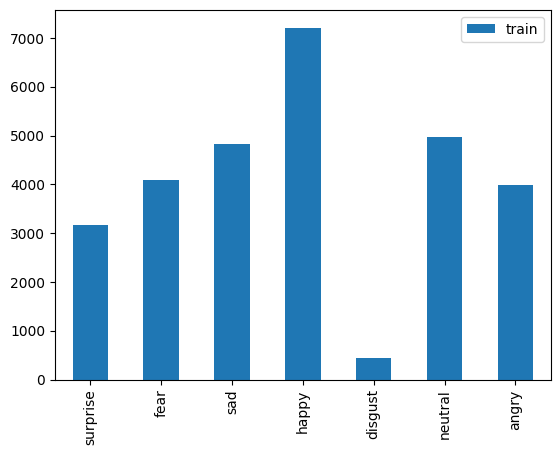

In [ ]:
train_count.transpose().plot(kind='bar')

Plot Number Of Images in Test Set

<Axes: >

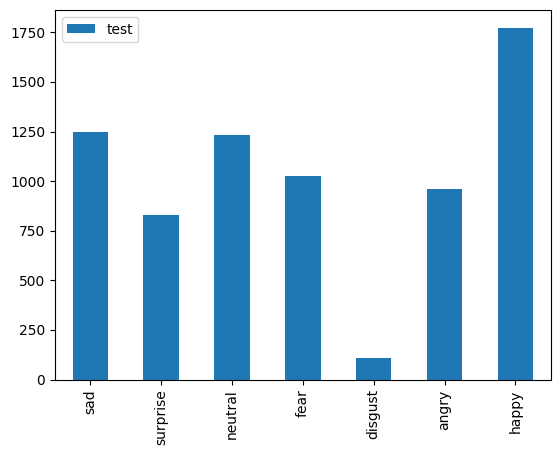

In [ ]:
test_count.transpose().plot(kind='bar')

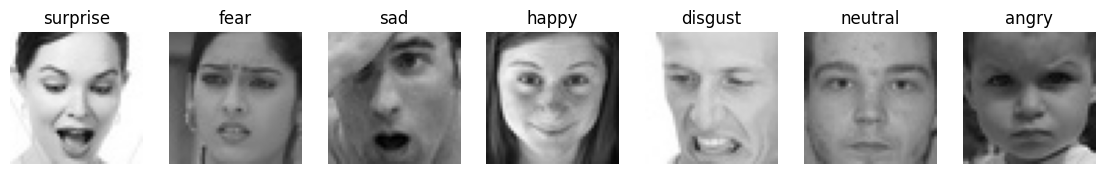

In [ ]:
plt.figure(figsize=(14,22))
i = 1
for expression in os.listdir(train_dir):
    img = load_img((train_dir + expression +'/'+ os.listdir(train_dir + expression)[1]))
    plt.subplot(1,7,i)
    plt.imshow(img)
    plt.title(expression)
    plt.axis('off')
    i += 1
plt.show()

Creating and Testing datasets

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   zoom_range=0.3,
                                   horizontal_flip=True)

training_set = train_datagen.flow_from_directory(train_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=True,
                                                color_mode='grayscale',
                                                class_mode='categorical')

test_datagen = ImageDataGenerator(rescale=1./255)
test_set = test_datagen.flow_from_directory(test_dir,
                                                batch_size=64,
                                                target_size=(48,48),
                                                shuffle=True,
                                                color_mode='grayscale',
                                                class_mode='categorical')


Found 28725 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
training_set.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

Defining Model

In [ ]:
def get_model(input_size, classes=7):
     #Initialising the CNN
    model = tf.keras.models.Sequential()

    model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape =input_size))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.01)))
    model.add(Conv2D(256, kernel_size=(3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(classes, activation='softmax'))

    #Compliling the model
    model.compile(optimizer=Adam(learning_rate=0.0001, decay=1e-6),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
fernet = get_model((row,col,1), classes)
fernet.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 22, 22, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 22, 22, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 11, 11, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 11, 11, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │      31,720,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           7,175 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,116,743 (122.52 MB)

 Trainable params: 32,116,103 (122.51 MB)

 Non-trainable params: 640 (2.50 KB)

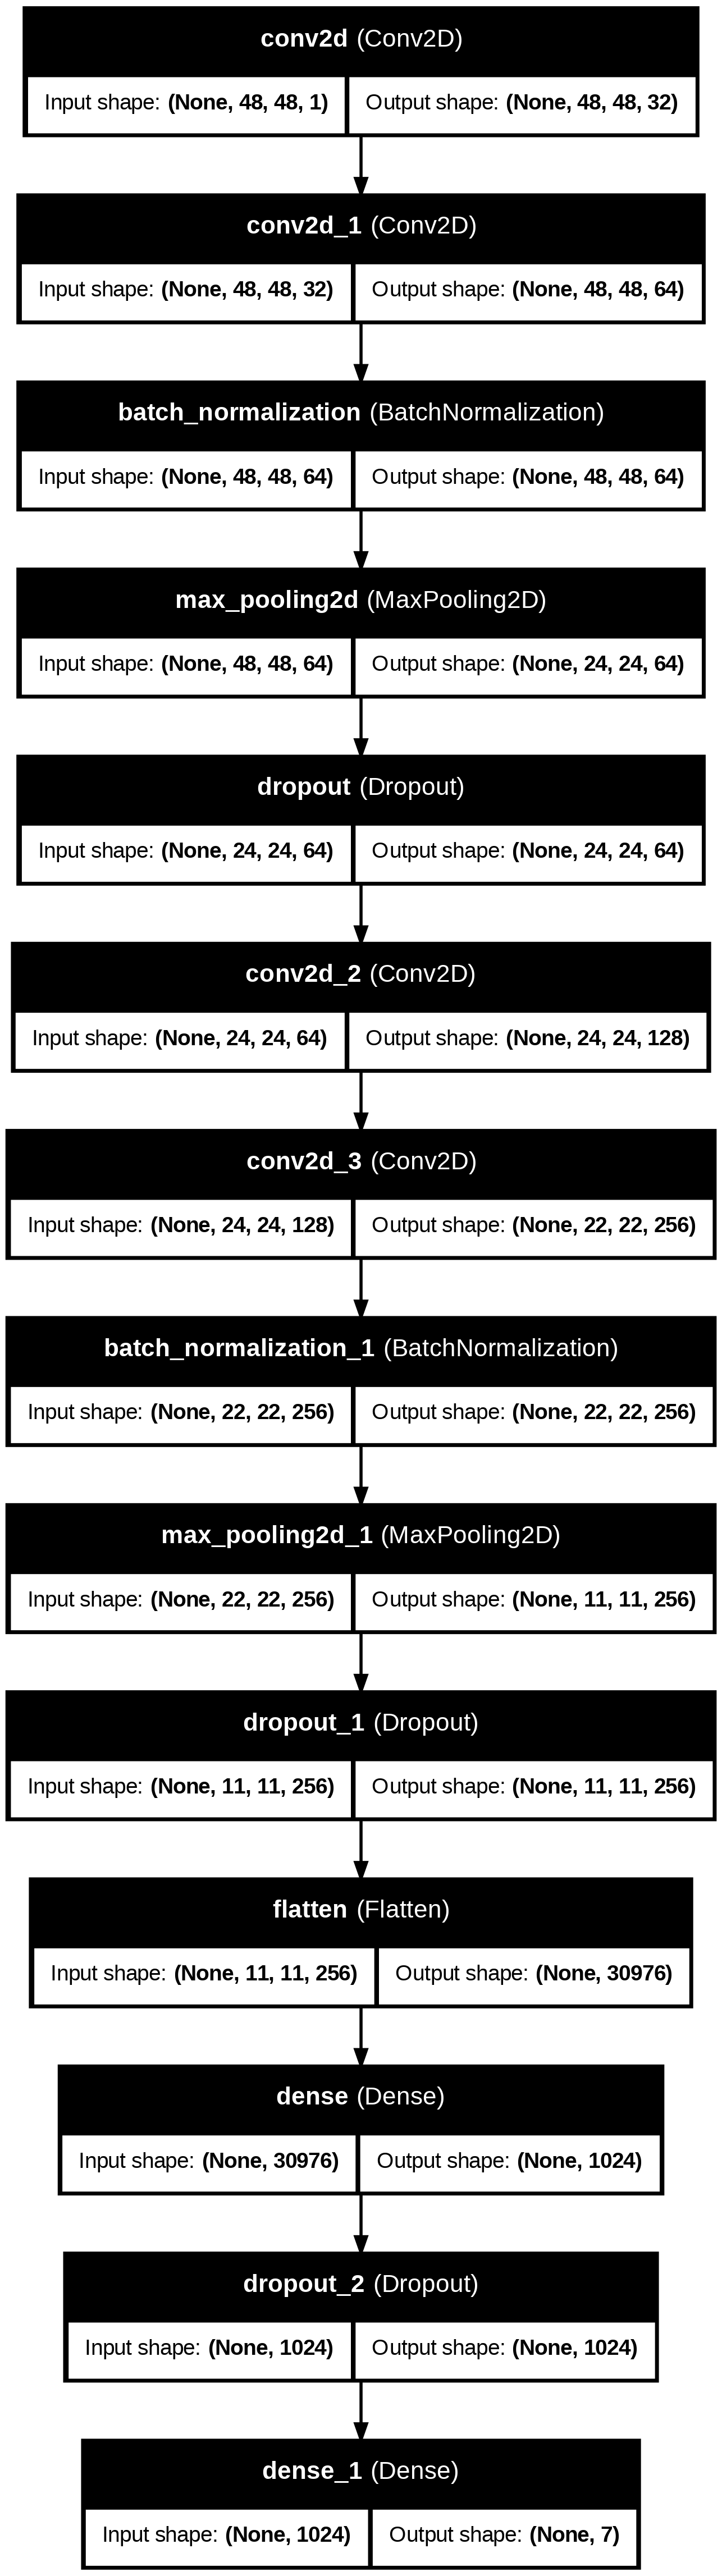

In [ ]:
plot_model(fernet, to_file='fernet.png', show_shapes=True, show_layer_names=True)

In [ ]:
# print the input shape

print(fernet.input_shape)


(None, 48, 48, 1)


CallBack FunC

In [ ]:
chk_path = 'ferNet.keras'  # Change the file extension to '.keras'
log_dir = "checkpoint/logs/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

checkpoint = ModelCheckpoint(filepath=chk_path,
                             save_best_only=True,
                             verbose=1,
                             mode='min',
                             monitor='val_loss')


earlystop = EarlyStopping(monitor='val_loss',
                          min_delta=0,
                          patience=3,
                          verbose=1,
                          restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=6,
                              verbose=1,
                              min_delta=0.0001)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
csv_logger = CSVLogger('training.log')

callbacks = [checkpoint, reduce_lr, csv_logger]

Training Model

In [ ]:
steps_per_epoch = training_set.n // training_set.batch_size
validation_steps = test_set.n // test_set.batch_size

hist = fernet.fit(x=training_set,
                 validation_data=test_set,
                 epochs=10,
                 callbacks=callbacks,
                 steps_per_epoch=steps_per_epoch,
                 validation_steps=validation_steps)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.2484 - loss: 4.9998 
Epoch 1: val_loss improved from inf to 6.04113, saving model to ferNet.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 7766s 17s/step - accuracy: 0.2485 - loss: 4.9983 - val_accuracy: 0.1713 - val_loss: 6.0411 - learning_rate: 1.0000e-04
Epoch 2/10
  1/448 ━━━━━━━━━━━━━━━━━━━━ 38:35 5s/step - accuracy: 0.3438 - loss: 3.7238

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Epoch 2: val_loss did not improve from 6.04113
448/448 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.3438 - loss: 3.7238 - val_accuracy: 0.1000 - val_loss: 7.2343 - learning_rate: 1.0000e-04
Epoch 3/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3271 - loss: 3.6416
Epoch 3: val_loss improved from 6.04113 to 3.14885, saving model to ferNet.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 1923s 4s/step - accuracy: 0.3271 - loss: 3.6413 - val_accuracy: 0.3952 - val_loss: 3.1489 - learning_rate: 1.0000e-04
Epoch 4/10
  1/448 ━━━━━━━━━━━━━━━━━━━━ 42:38 6s/step - accuracy: 0.2656 - loss: 3.3170
Epoch 4: val_loss improved from 3.14885 to 3.13086, saving model to ferNet.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.2656 - loss: 3.3170 - val_accuracy: 0.4000 - val_loss: 3.1309 - learning_rate: 1.0000e-04
Epoch 5/10
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3650 - loss: 3.1104
Epoch 5: val_loss improved from 3.13086 to 2.71623, saving model to ferNet.keras
448/448 ━━━━

In [ ]:
# Check if the model is trained
if os.path.exists('ferNet.keras'):
  print("Model is trained and saved as ferNet.keras")
else:
  print("Model is not trained yet.")


Model is trained and saved as ferNet.keras


Loss and Accuracy plot

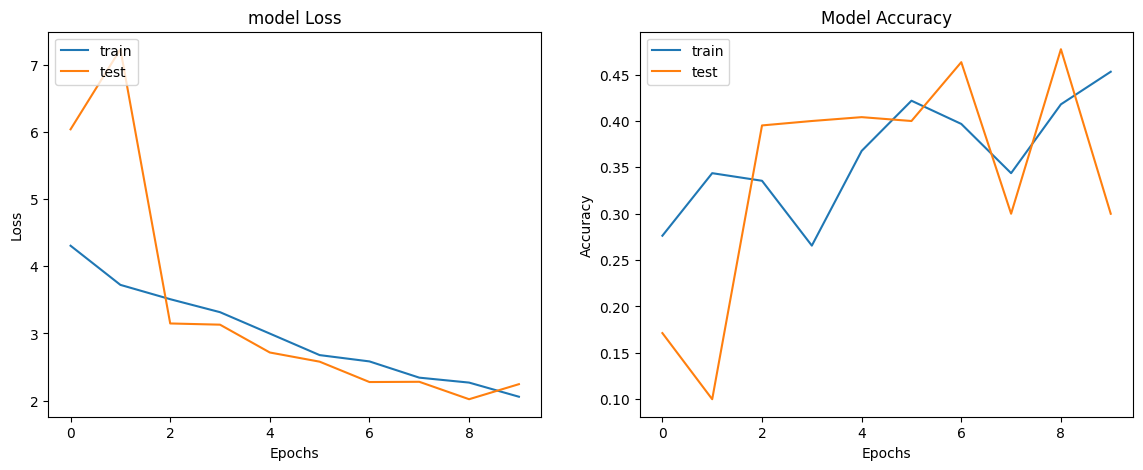

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'test'], loc='upper left')

plt.subplot(1,2,1)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Model Evaluation

In [ ]:
train_loss, train_accu = fernet.evaluate(training_set)
test_loss, test_accu = fernet.evaluate(test_set)
print("final train accuracy = {:.2f} , validation accuracy = {:.2f}".format(train_accu*100, test_accu*100))

449/449 ━━━━━━━━━━━━━━━━━━━━ 518s 1s/step - accuracy: 0.4672 - loss: 2.0441
113/113 ━━━━━━━━━━━━━━━━━━━━ 111s 978ms/step - accuracy: 0.4830 - loss: 2.0171
final train accuracy = 46.76 , validation accuracy = 47.78


In [ ]:
fernet.save_weights('fernet_bestweight.h5.weights.h5')

confusion Matrix and classification on training set

449/449 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step
Confusion Matrix
[[ 533    0  232 1183  980  570  497]
 [  70    0   21  114  110   69   52]
 [ 521    4  230 1155 1042  590  555]
 [1033    8  389 1997 1804 1055  929]
 [ 648    2  286 1368 1291  732  648]
 [ 635    1  252 1358 1283  679  628]
 [ 436    2  175  879  827  404  448]]
Classification Report
              precision    recall  f1-score   support

       angry       0.14      0.13      0.14      3995
     disgust       0.00      0.00      0.00       436
        fear       0.15      0.06      0.08      4097
       happy       0.25      0.28      0.26      7215
     neutral       0.18      0.26      0.21      4975
         sad       0.17      0.14      0.15      4836
    surprise       0.12      0.14      0.13      3171

    accuracy                           0.18     28725
   macro avg       0.14      0.14      0.14     28725
weighted avg       0.17      0.18      0.17     28725



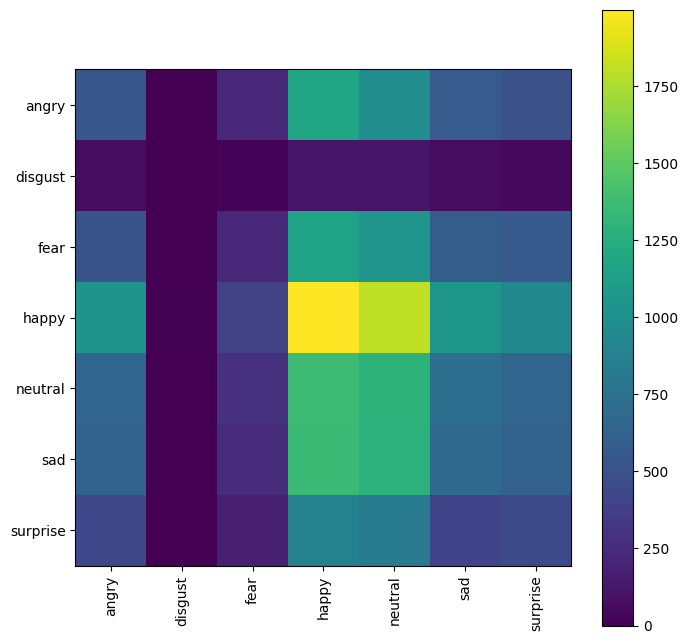

In [ ]:
y_pred = fernet.predict(training_set)
y_pred = np.argmax(y_pred, axis=1)
class_labels = test_set.class_indices
class_labels = {v:k for k,v in class_labels.items()}

from sklearn.metrics import classification_report, confusion_matrix
cm_train = confusion_matrix(training_set.classes, y_pred)
print('Confusion Matrix')
print(cm_train)
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(training_set.classes, y_pred, target_names=target_names))

plt.figure(figsize=(8,8))
plt.imshow(cm_train, interpolation='nearest')
plt.colorbar()
tick_mark = np.arange(len(target_names))
_ = plt.xticks(tick_mark, target_names, rotation=90)
_ = plt.yticks(tick_mark, target_names)

Confusion Matric and classification on Test set

113/113 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step
Confusion Matrix
[[166   0  61 280 219  94 138]
 [ 15   0   8  28  29   9  22]
 [174   2  67 299 240 102 140]
 [307   0 131 434 412 190 300]
 [214   0  90 319 301 128 181]
 [217   0  96 318 291 128 197]
 [151   0  68 215 177  78 142]]
Classification Report
              precision    recall  f1-score   support

       angry       0.13      0.17      0.15       958
     disgust       0.00      0.00      0.00       111
        fear       0.13      0.07      0.09      1024
       happy       0.23      0.24      0.24      1774
     neutral       0.18      0.24      0.21      1233
         sad       0.18      0.10      0.13      1247
    surprise       0.13      0.17      0.15       831

    accuracy                           0.17      7178
   macro avg       0.14      0.14      0.14      7178
weighted avg       0.17      0.17      0.17      7178



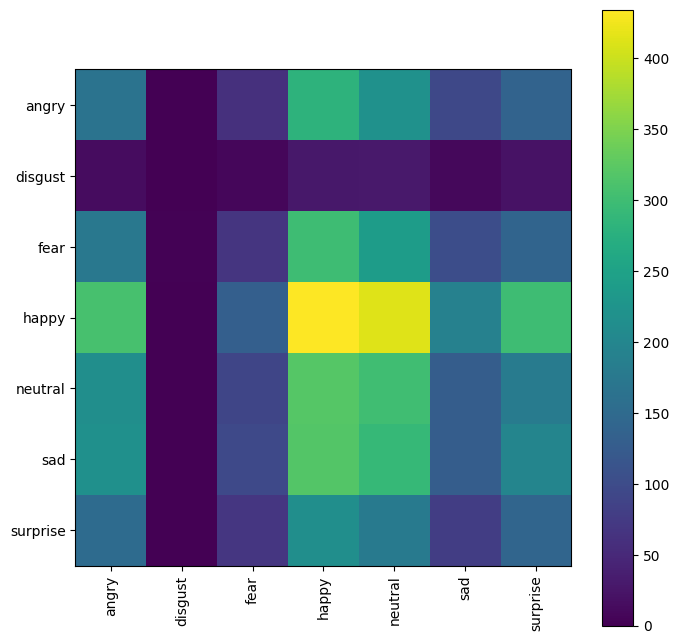

In [ ]:
y_pred = fernet.predict(test_set)
y_pred = np.argmax(y_pred, axis=1)
class_labels = test_set.class_indices
class_labels = {v:k for k,v in class_labels.items()}

#from sklearn.metrics import classification_report, confusion_matrix
cm_test = confusion_matrix(test_set.classes, y_pred)
print('Confusion Matrix')
print(cm_test)
print('Classification Report')
target_names = list(class_labels.values())
print(classification_report(test_set.classes, y_pred, target_names=target_names))

plt.figure(figsize=(8,8))
plt.imshow(cm_test, interpolation='nearest')
plt.colorbar()
tick_mark = np.arange(len(target_names))
_ = plt.xticks(tick_mark, target_names, rotation=90)
_ = plt.yticks(tick_mark, target_names)

**Audio Recognition**

In [ ]:
import pandas as pd
import numpy as np

import os
import sys
import random

# librosa is a Python library for analyzing audio and music.
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# to play the audio files
from IPython.display import Audio

from tensorflow.keras import backend as K
import tensorflow as tf
tf.random.set_seed(30)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GRU, LSTM, Flatten, TimeDistributed, BatchNormalization, Activation
from tensorflow.keras.layers import Conv3D, MaxPooling3D, Conv2D, MaxPooling2D, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras import optimizers

#from keras.layers.recurrent import LSTM
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from keras import optimizers
from keras.optimizers import Adam
from keras.layers import Dropout

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# Paths for data.
Ravdess = "/content/drive/MyDrive/MERK/Datasets/speech-emotion-recognition-ravdess-data"

In [ ]:
ravdess_directory_list = os.listdir(Ravdess)
file_emotion = []
file_statement = []
file_path = []
for dir in ravdess_directory_list:
    # as their are 20 different actors in our previous directory we need to extract files for each actor.
    actor = os.listdir(os.path.join(Ravdess, dir))
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # third part in each file represents the emotion associated to that auido.
        if len(part) == 7:  # Ensure the list has exactly 7 elements
            file_emotion.append(int(part[2]))
            file_statement.append(int(part[4]))
            file_path.append(Ravdess + dir + '/' + file)

# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])

#Ravdess_df = pd.concat([emotion_df, path_df], axis=1)
Ravdess_df = pd.DataFrame({"Emotions":file_emotion, "Statement":file_statement, "Path":file_path})

# changing integers to actual emotions.
Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)
Ravdess_df.head()

,Emotions,Statement,Path
0,neutral,2,/content/drive/MyDrive/MERK/Datasets/speech-em...
1,neutral,2,/content/drive/MyDrive/MERK/Datasets/speech-em...
2,calm,1,/content/drive/MyDrive/MERK/Datasets/speech-em...
3,calm,1,/content/drive/MyDrive/MERK/Datasets/speech-em...
4,calm,2,/content/drive/MyDrive/MERK/Datasets/speech-em...


In [ ]:
Ravdess_df.shape

(1440, 3)

In [ ]:
Ravdess_df.groupby(['Emotions','Statement']).size().unstack()

Statement,1,2
Emotions,,
angry,96,96
calm,96,96
disgust,96,96
fear,96,96
happy,96,96
neutral,48,48
sad,96,96
surprise,96,96


In [ ]:
# creating a copy
data_path = Ravdess_df[['Emotions','Path']].copy()
data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,neutral,/content/drive/MyDrive/MERK/Datasets/speech-em...
1,neutral,/content/drive/MyDrive/MERK/Datasets/speech-em...
2,calm,/content/drive/MyDrive/MERK/Datasets/speech-em...
3,calm,/content/drive/MyDrive/MERK/Datasets/speech-em...
4,calm,/content/drive/MyDrive/MERK/Datasets/speech-em...


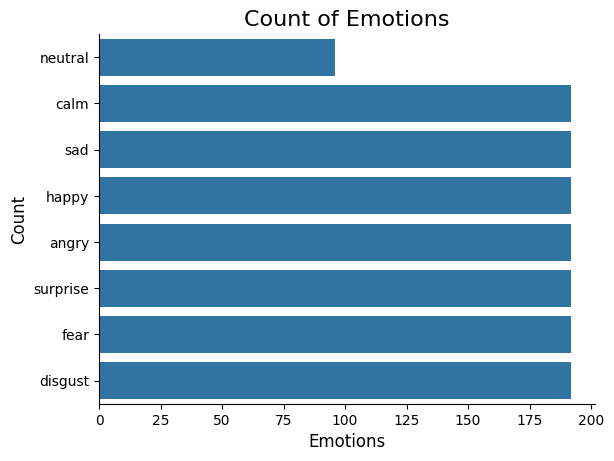

In [ ]:
plt.title('Count of Emotions', size=16)
sns.countplot(data_path.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

In [ ]:
Ravdess = '/content/drive/MyDrive/MERK/Datasets/speech-emotion-recognition-ravdess-data/'

ravdess_directory_list = os.listdir(Ravdess)
file_emotion = []
file_statement = []
file_path = []


for dir in ravdess_directory_list:
    actor_dir = os.path.join(Ravdess, dir)
    actor_files = os.listdir(actor_dir)
    for file in actor_files:
        part = file.split('.')[0].split('-')
        if len(part) == 7:  # Ensure the part list has exactly 7 elements
            file_emotion.append(int(part[2]))
            file_statement.append(int(part[4]))
            file_path.append(os.path.join(actor_dir, file))
        else:
            print(f"Unexpected file format: {file}")

Ravdess_df = pd.DataFrame({"Emotions": file_emotion, "Statement": file_statement, "Path": file_path})
Ravdess_df.Emotions.replace({1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fear', 7: 'disgust', 8: 'surprise'}, inplace=True)

# Copy DataFrame to data_path for further processing
data_path = Ravdess_df.copy()

In [ ]:
Ravdess_df.tail(10)

,Emotions,Statement,Path
1430,fear,2,/content/drive/MyDrive/MERK/Datasets/speech-em...
1431,surprise,2,/content/drive/MyDrive/MERK/Datasets/speech-em...
1432,surprise,1,/content/drive/MyDrive/MERK/Datasets/speech-em...
1433,surprise,2,/content/drive/MyDrive/MERK/Datasets/speech-em...
1434,surprise,1,/content/drive/MyDrive/MERK/Datasets/speech-em...
1435,disgust,2,/content/drive/MyDrive/MERK/Datasets/speech-em...
1436,surprise,1,/content/drive/MyDrive/MERK/Datasets/speech-em...
1437,surprise,1,/content/drive/MyDrive/MERK/Datasets/speech-em...
1438,surprise,2,/content/drive/MyDrive/MERK/Datasets/speech-em...
1439,surprise,2,/content/drive/MyDrive/MERK/Datasets/speech-em...


In [ ]:
def create_waveplot(data, sr):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio', size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def create_spectrogram(data, sr):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio', size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

/content/drive/MyDrive/MERK/Datasets/speech-emotion-recognition-ravdess-data/Actor_17/03-01-06-01-02-01-17.wav


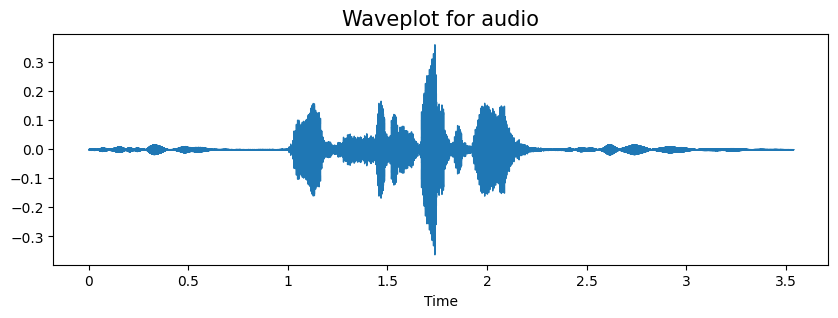

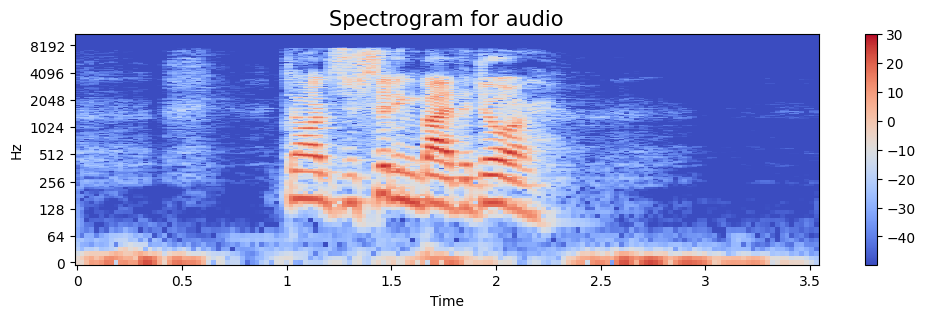

In [ ]:
Ravdess = '/content/drive/MyDrive/MERK/Datasets/speech-emotion-recognition-ravdess-data/'

ravdess_directory_list = os.listdir(Ravdess)
file_emotion = []
file_statement = []
file_path = []

for dir in ravdess_directory_list:
    actor_dir = os.path.join(Ravdess, dir)
    actor_files = os.listdir(actor_dir)
    for file in actor_files:
        if file.endswith('.wav'):  # Process only .wav files
            part = file.split('.')[0].split('-')
            if len(part) == 7:  # Ensure the part list has exactly 7 elements
                file_emotion.append(int(part[2]))
                file_statement.append(int(part[4]))
                file_path.append(os.path.join(actor_dir, file))
            else:
                print(f"Unexpected file format: {file}")
        else:
            print(f"Skipping non-audio file: {file}")  # Skip non-wav files

Ravdess_df = pd.DataFrame({"Emotions": file_emotion, "Statement": file_statement, "Path": file_path})
Ravdess_df.Emotions.replace({1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fear', 7: 'disgust', 8: 'surprise'}, inplace=True)

# Copy DataFrame to data_path for further processing
data_path = Ravdess_df.copy()

# Check if paths are constructed correctly
emotion = 'fear'
filtered_paths = data_path.Path[data_path.Emotions == emotion]
if not filtered_paths.empty:
    path = filtered_paths.iloc[1]  # Use iloc to avoid np.array
    print(path)  # Print path to verify correctness

    # Load the audio file and create waveplot and spectrogram
    data, sampling_rate = librosa.load(path)
    create_waveplot(data, sampling_rate)
    create_spectrogram(data, sampling_rate)
    Audio(path)
else:
    print(f"No files found for emotion: {emotion}")


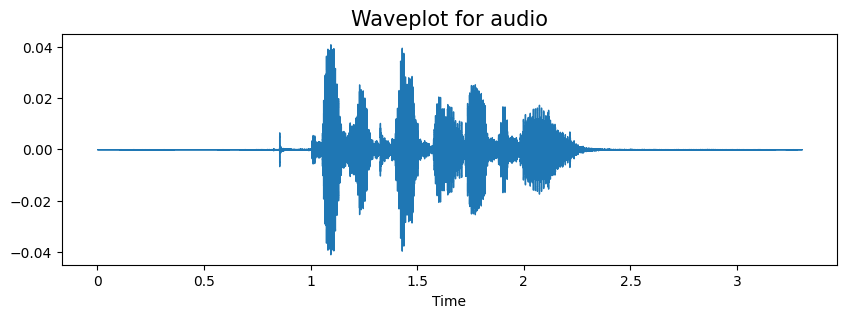

In [ ]:
path = "/content/drive/MyDrive/MERK/Datasets/speech-emotion-recognition-ravdess-data/Actor_01/03-01-01-01-01-01-01.wav"
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate)
Audio(path)

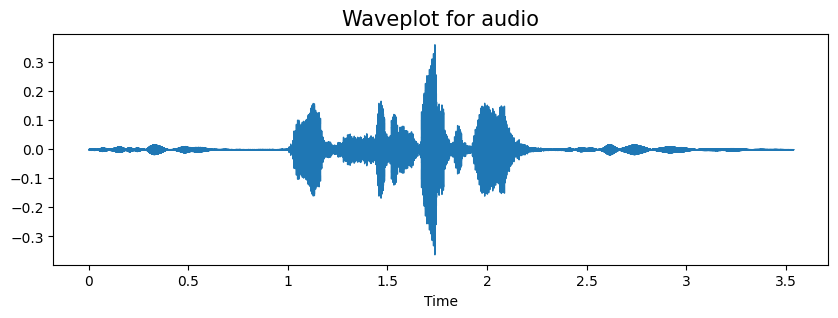

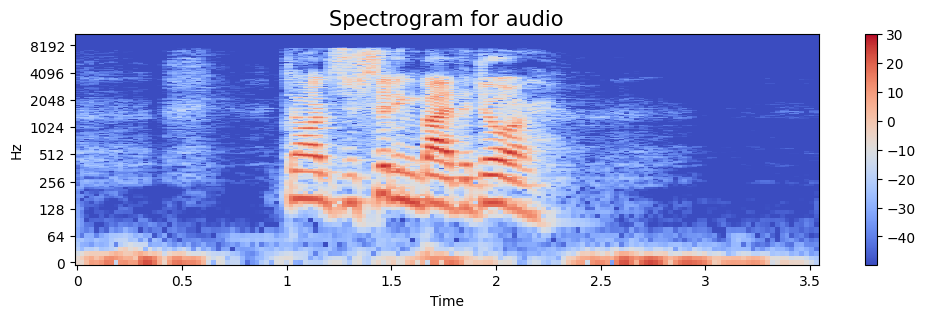

In [ ]:
emotion='fear'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate)
create_spectrogram(data, sampling_rate)
Audio(path)

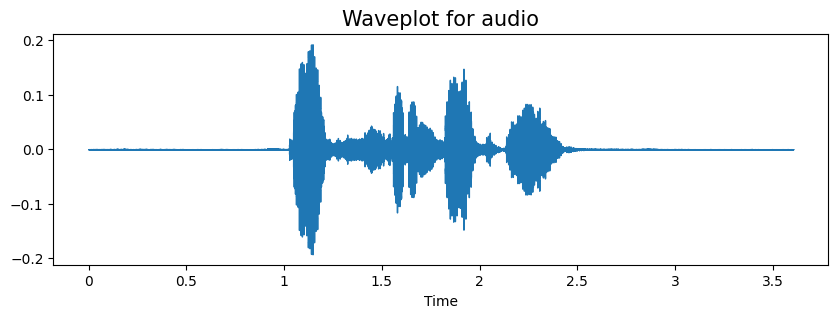

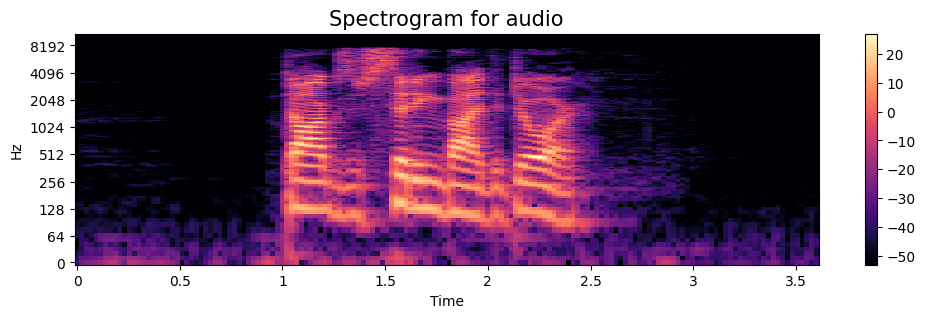

In [ ]:
emotion='angry'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate)
create_spectrogram(data, sampling_rate)
Audio(path)

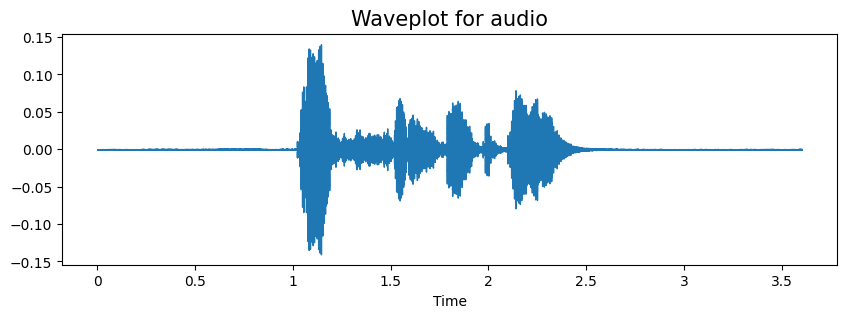

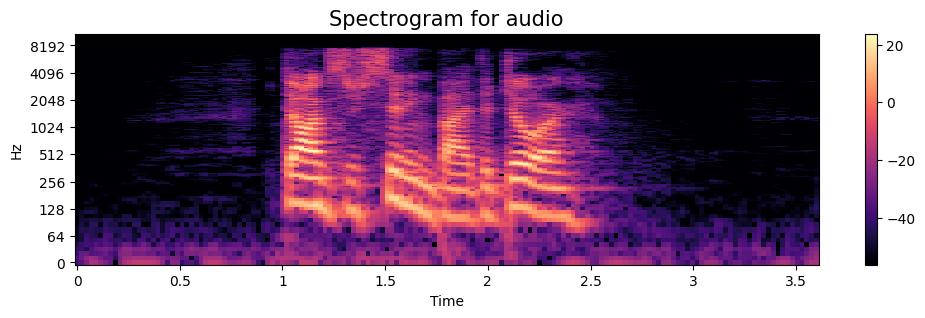

In [ ]:
emotion='sad'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate)
create_spectrogram(data, sampling_rate)
Audio(path)

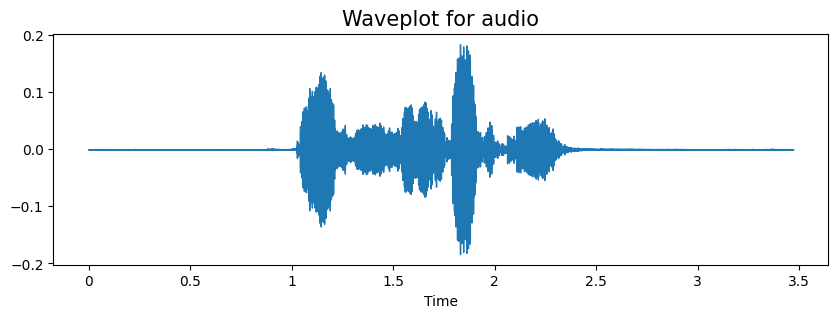

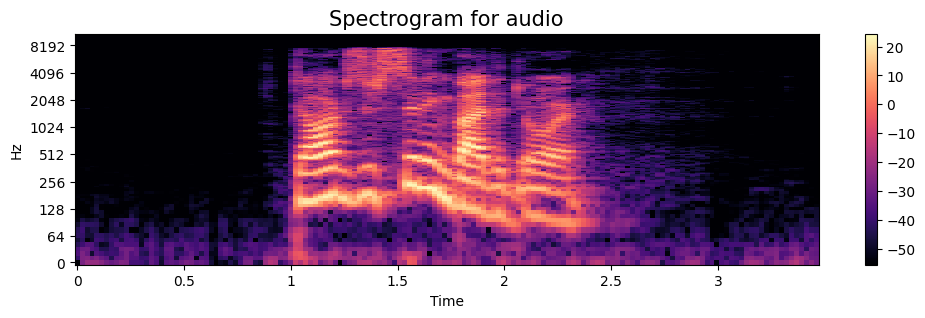

In [ ]:
emotion='happy'
path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate)
create_spectrogram(data, sampling_rate)
Audio(path)

Data Augmentation

In [ ]:
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.85):
    return librosa.effects.time_stretch(data, rate)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sampling_rate, pitch_factor)

# taking any example and checking for techniques.
path = np.array(data_path.Path)[1]
data, sample_rate = librosa.load(path)

Simple Audio

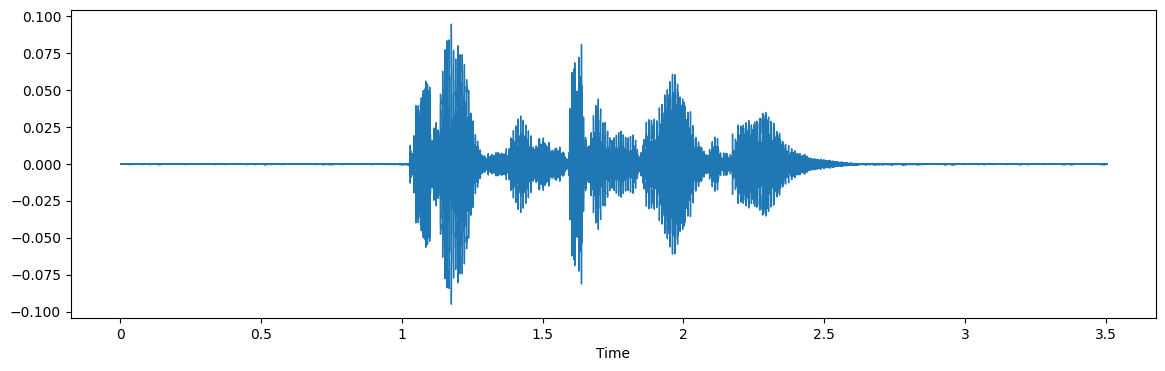

In [ ]:
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
Audio(path)

Noise Injection

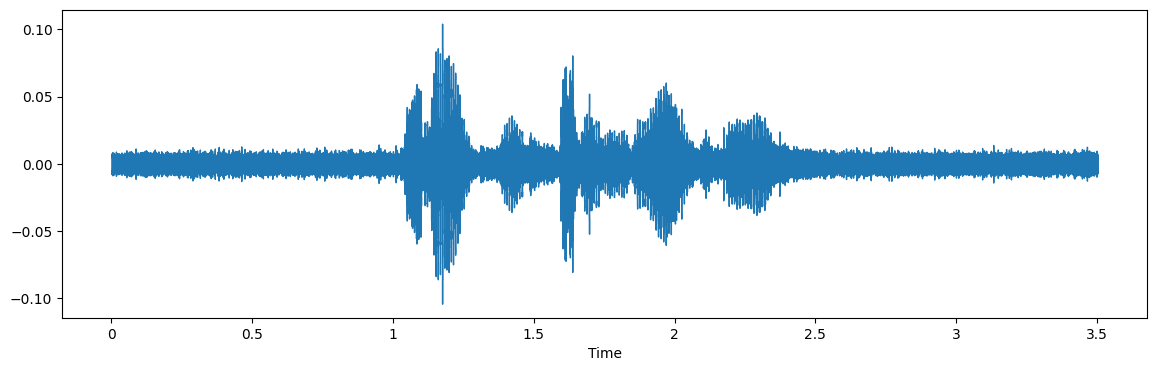

In [ ]:
x = noise(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

Stretching Noise

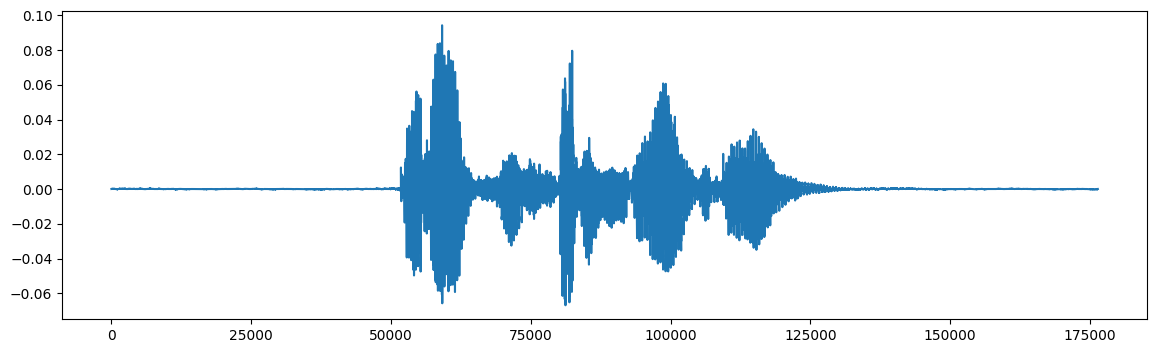

In [ ]:
def stretch(data, target_duration, sample_rate):
    # Compute the current duration of the audio data
    current_duration = len(data) / sample_rate

    # Compute the length of the stretched data
    target_length = int(target_duration * sample_rate)

    # Interpolate the audio data to stretch or compress it to the target length
    stretched_data = np.interp(np.linspace(0, len(data), target_length), np.arange(len(data)), data)

    return stretched_data

# Define the target duration for time stretching (in seconds)
target_duration = 8.0  # can be adjusted as needed

# Perform time stretching
x_stretched = stretch(data, target_duration, sample_rate)

# Plot the stretched audio
plt.figure(figsize=(14,4))
plt.plot(x_stretched)

# Play the stretched audio
Audio(x_stretched, rate=sample_rate)


Shifting Audio

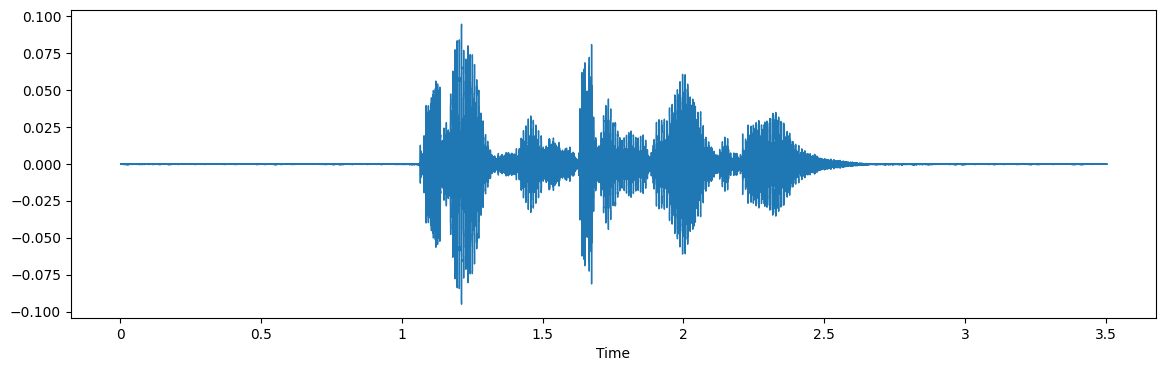

In [ ]:
x = shift(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

The Pitch

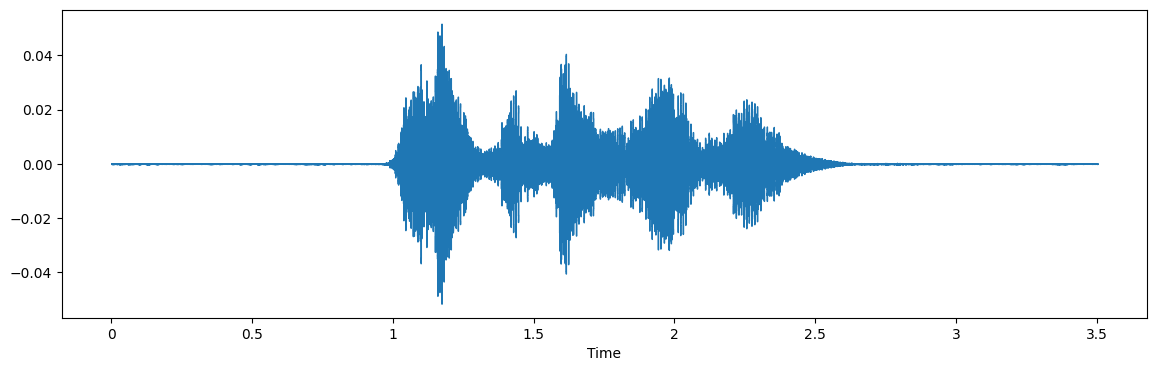

In [ ]:
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)

# Taking any example and checking for techniques.
path = np.array(data_path.Path)[1]
data, sample_rate = librosa.load(path)

x = pitch(data, sample_rate)
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y=x, sr=sample_rate)
plt.show()

# Display the audio player
Audio(x, rate=sample_rate)

Feature extraction

In [ ]:
def extract_features(data):
    # MFCC
    mfcc = librosa.feature.mfcc(y=data, sr=sample_rate)
    result = mfcc
    return result

# funtion to transform audio
def transform_audio(data, fns):
    fn = random.choice(fns)
    if fn == pitch:
        fn_data = fn(data, sampling_rate)
    elif fn == "None":
        fn_data = data
    elif fn in [noise, stretch]:
        fn_data = fn(data)
    else:
        fn_data = data
    return fn_data
def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)


    #randomly transforming audio data
    fns = [noise, pitch, "None"]

    fn1_data = transform_audio(data, fns)
    fn2_data = transform_audio(fn1_data, fns)
    res1 = extract_features(fn2_data)
    result = [np.array(res1[:,:108])]

    fn1_data = transform_audio(data, fns)
    fn2_data = transform_audio(fn1_data, fns)
    res2 = extract_features(fn2_data)[:,:108]
    result.append(res2)#np.vstack((result, res2)) # stacking vertically

    fn1_data = transform_audio(data, fns)
    fn2_data = transform_audio(fn1_data, fns)
    res3 = extract_features(fn2_data)[:,:108]
    result.append(res3)#np.vstack((result, res3)) # stacking vertically
    return result

In [ ]:
path = "/content/drive/MyDrive/MERK/Datasets/speech-emotion-recognition-ravdess-data/Actor_01/03-01-01-01-01-01-01.wav"
data, sampling_rate = librosa.load(path, duration=2.5, offset=0.6)

Audio(path)
xx1 = librosa.feature.zero_crossing_rate(data)
stft = np.abs(librosa.stft(data))
xx2 = librosa.feature.chroma_stft(S=stft, sr=sample_rate)
xx3 = librosa.feature.mfcc(y=data, sr=sample_rate)
xx4 = librosa.feature.rms(y=data)
xx5 = librosa.feature.melspectrogram(y=data, sr=sample_rate)
xx1.shape, xx2.shape, xx3.shape, xx4.shape, xx5.shape, np.append(xx1,xx2,axis=0).shape


((1, 108), (12, 108), (20, 108), (1, 108), (128, 108), (13, 108))

In [ ]:
X, Y = [], []
for path, emotion in zip(data_path.Path.to_list(), data_path.Emotions.to_list()):
    feature = get_features(path)
    for ele in feature:
        if ele.shape == (20, 108):
            X.append(ele)
            # appending emotion as we have made augmentation techniques on each audio file.
            Y.append(emotion)
        else:
            print(ele.shape)

(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 104)
(20, 104)
(20, 104)
(20, 105)
(20, 105)
(20, 105)
(20, 101)
(20, 101)
(20, 101)
(20, 107)
(20, 107)
(20, 107)
(20, 105)
(20, 105)
(20, 105)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 107)
(20, 103)
(20, 103)
(20, 103)
(20, 107)
(20, 107)
(20, 107)


In [ ]:
len(X), len(Y), data_path.Path.shape

(4275, 4275, (1440,))

In [ ]:
dfm = pd.DataFrame()
xx = pd.Series(X)
for i in range(20):
    dfm[i] = [k[i] for k in xx]

In [ ]:
Features = dfm.copy()
Features['labels'] = Y
Features.to_csv('features.csv', index=False)
Features.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,labels
0,"[-516.2539627465299, -484.51682857516056, -497...","[4.213122617943791, -2.5484231389236713, -2.61...","[2.142203526569584, -4.835481115378932, -1.238...","[1.7236742438182762, -0.9448332957713578, -1.1...","[-3.6595344243368046, -4.959691002744313, -5.1...","[3.869905944257228, 2.2290981051961265, 2.5664...","[6.071845288596616, 2.6120614081803604, 2.2879...","[-6.055369135702488, -0.23699489655397668, 4.9...","[-6.155104019569552, -2.869126017279634, -1.26...","[6.685057058093308, -0.18065632010185784, -2.8...",...,"[4.83082339800584, 6.0683430117707475, 6.47625...","[-2.1200354037466975, -1.4474165044203948, -1....","[-1.493506575858083, 0.87835625121972, 1.92663...","[-8.222423488044534, -5.1580752642472785, 0.15...","[0.6118180092267891, 2.7190893768215263, 5.563...","[-3.7783414990063577, -1.0942928612165392, 2.9...","[0.4480005736602397, 1.589672598177645, 2.5291...","[-0.938179263626101, -1.7185522273267875, -4.0...","[2.1980306615075884, 4.328692832320693, 3.6134...",neutral
1,"[-509.039017114762, -465.5248046475848, -460.7...","[-12.255316488963881, -2.601514824430826, 1.27...","[1.0472254025961025, 4.415284617251917, 3.9583...","[3.2204834181789646, 1.6722191396368475, 2.348...","[-7.761883793398285, -6.3927669289744555, 1.68...","[-11.614712639088744, -6.616163222551807, -3.7...","[-4.708270316542403, 0.9530830081081507, 0.826...","[2.9461314985007356, 0.8176678233593326, 1.718...","[-0.6462818317029284, -1.0161977296336833, -2....","[1.7034662359273907, 3.015610615362545, 4.3389...",...,"[2.1772193888579365, 4.250288636256675, 7.1432...","[0.3972275337549629, 2.7009536454436778, 1.342...","[-0.21420027300115496, 5.318539544781167, 5.82...","[0.18648618543480022, 3.1554582289631306, 2.95...","[2.8234910710566434, 4.288994698752576, 2.2404...","[-2.302340552540506, 1.6632208782388447, 2.437...","[-1.1847049183386522, 0.22435125821760277, 0.7...","[-4.021292528221155, 1.1033947626681777, -1.03...","[-11.217355211410547, -2.975051465442439, 2.27...",neutral
2,"[-443.3442047841361, -402.63059460226935, -400...","[-11.154527252457271, -7.340011640156886, -7.4...","[1.3794436614047223, -1.3322816467012326, -2.1...","[5.160578657595539, 0.5042050228623923, -1.616...","[-2.5471118168834948, -3.483278381150029, 0.55...","[-10.914603289291005, -1.129006879223797, 3.25...","[-8.46576505185489, -3.3108970902521433, -2.08...","[-3.27239130444325, -2.6071835198213953, -4.26...","[-3.984808521612262, -2.2705546715602694, -3.9...","[1.1596028180701552, 0.03964021040826665, -2.2...",...,"[-4.968033686536668, 2.775034992471318, 3.8713...","[-7.154614787482398, -2.9751054316389354, 0.78...","[-0.45727500042874547, -2.450524461282186, 1.0...","[1.5161325079446621, -1.4033905063749843, 1.23...","[-4.745290003545444, -2.0238186148229658, 2.33...","[-2.7426056674891934, 1.7775967646811157, 3.09...","[-0.37178505374739845, -2.71433842220111, -1.4...","[-1.8403603505363662, -1.3704415265292922, -1....","[-0.5243137056977756, 2.715184722077501, 2.546...",neutral
3,"[-401.978910198529, -370.54845397060853, -364....","[-4.489295464566647, -9.711337520307362, -7.24...","[2.3403352557093884, -0.8280960238859681, -7.0...","[-2.375228793219102, -4.57085639957007, -6.120...","[-4.757866282678211, -7.4787658608793315, -4.1...","[-2.4722824692928818, -4.282912582463465, -3.5...","[2.812878291727338, 0.020269770849878854, -0.0...","[3.612586782483854, 1.8189451882792111, -3.413...","[4.440215171318173, 1.0898978982841785, -2.536...","[2.3805342234552054, -1.4331580113000226, -1.5...",...,"[1.9680932730184724, -3.957393732968442, -2.42...","[-3.8293066676353558, -4.211424639441528, 0.23...","[-4.147941337960635, -3.88479204264214, -0.439...","[-0.12592006818416812, -1.086573873407925, 1.0...","[-0.24075573590980506, 1.4532362115425106, 1.7...","[1.7045621391790005, 2.292040900394382, 0.3742...","[1.0918836847539937, 2.935372934056053, 3.1234...","[-1.3445109376956625, 7.2206557210654445, 4.

In [ ]:
X = np.array(X)
Y = np.array(Y)
X.shape, Y.shape

((4275, 20, 108), (4275,))

Data Preparation

In [ ]:
# As this is a multiclass classification problem onehotencoding our Y.
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [ ]:
# splitting data
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=21, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((3420, 20, 108), (3420, 8), (855, 20, 108), (855, 8))

In [ ]:
# making data compatible to model.
x_train = np.expand_dims(x_train, axis=3)
x_train = np.swapaxes(x_train, 1, 2)
x_train = np.expand_dims(x_train, axis=3)

x_test = np.expand_dims(x_test, axis=3)
x_test = np.swapaxes(x_test, 1, 2)
x_test = np.expand_dims(x_test, axis=3)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((3420, 108, 20, 1, 1), (3420, 8), (855, 108, 20, 1, 1), (855, 8))

In [ ]:
# Save the compatible data into .npy files
np.save('x_train.npy', x_train)
np.save('y_train.npy', y_train)
np.save('x_test.npy', x_test)
np.save('y_test.npy', y_test)


In [ ]:
# display x and y shape

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (4275, 20, 108)
Y shape: (4275, 8)


Modeling

In [ ]:
input_shape = x_train.shape[1:]
input_shape

(108, 20, 1, 1)

In [ ]:
model=Sequential()

# Reshape the input_shape to be compatible with Conv1D
input_shape = (input_shape[0], input_shape[1], input_shape[2] * input_shape[3])

model.add(TimeDistributed(Conv1D(16, 3, padding='same', activation='relu'),
                            input_shape=input_shape))
model.add(TimeDistributed(BatchNormalization()))
#model.add(TimeDistributed(MaxPooling2D((2,1))))

model.add(TimeDistributed(Flatten()))
model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(units=8, activation='softmax'))

model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ time_distributed (TimeDistributed)   │ (None, 108, 20, 16)         │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_1 (TimeDistributed) │ (None, 108, 20, 16)         │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 108, 320)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 32)                  │          45,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             264 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,632 (182.16 KB)

 Trainable params: 46,600 (182.03 KB)

 Non-trainable params: 32 (128.00 B)

In [ ]:
from keras.optimizers import Adam
optimizer = Adam()
model.compile(optimizer=optimizer,
              loss = 'categorical_crossentropy',
              metrics=['accuracy'])

rlrp = ReduceLROnPlateau(monitor='val_loss', factor=0.5, verbose=1, patience=4, min_lr=0.0000001)

epochs = 50
history = model.fit(x_train, y_train, batch_size=128, epochs=epochs, validation_data=(x_test, y_test), callbacks=[rlrp])

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 131s 3s/step - accuracy: 0.1437 - loss: 2.1010 - val_accuracy: 0.2140 - val_loss: 2.0213 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.2103 - loss: 2.0028 - val_accuracy: 0.2164 - val_loss: 1.9681 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.2328 - loss: 1.9454 - val_accuracy: 0.2561 - val_loss: 1.8826 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.2953 - loss: 1.8489 - val_accuracy: 0.3509 - val_loss: 1.7438 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.3622 - loss: 1.7088 - val_accuracy: 0.3743 - val_loss: 1.6535 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4116 - loss: 1.5946 - val_accuracy: 0.4444 - val_loss: 1.5314 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.4355 - loss: 1.5064 - val_accuracy

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6818 - loss: 0.9498
Accuracy of our model on test data :  66.43275022506714 %


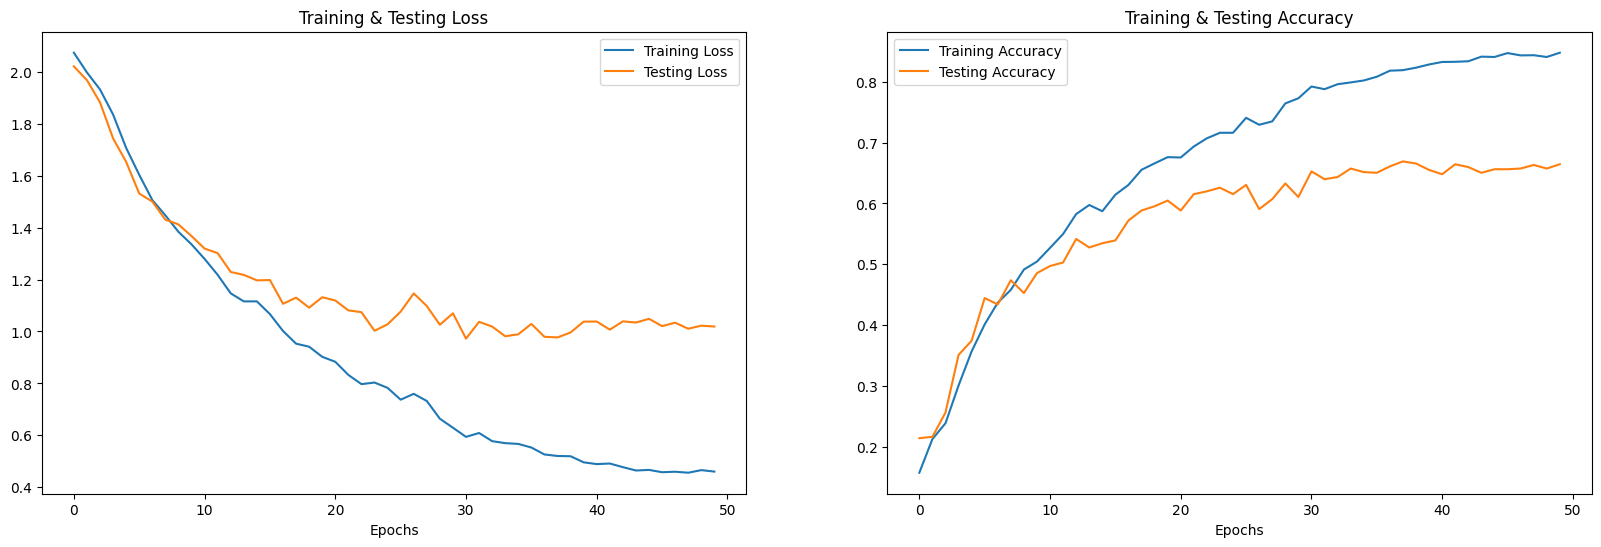

In [ ]:
print("Accuracy of our model on test data : " , model.evaluate(x_test,y_test)[1]*100 , "%")

epochs = [i for i in range(50)]
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [ ]:
#save the trained LSTM model
model.save('lstm_model.keras')


In [ ]:
import os

# Check if the model is trained
if os.path.exists('lstm_model.keras'):
  print("The trained model has been saved successfully.")
else:
  print("The trained model was not saved.")


The trained model has been saved successfully.


In [ ]:
# predicting on test data.
pred_test = model.predict(x_test)
y_pred = encoder.inverse_transform(pred_test)

y_test = encoder.inverse_transform(y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step


In [ ]:
df = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df['Predicted Labels'] = y_pred.flatten()
df['Actual Labels'] = y_test.flatten()

df.head(10)

,Predicted Labels,Actual Labels
0,fear,fear
1,disgust,disgust
2,surprise,surprise
3,calm,calm
4,surprise,surprise
5,sad,disgust
6,sad,sad
7,happy,happy
8,neutral,sad
9,calm,calm


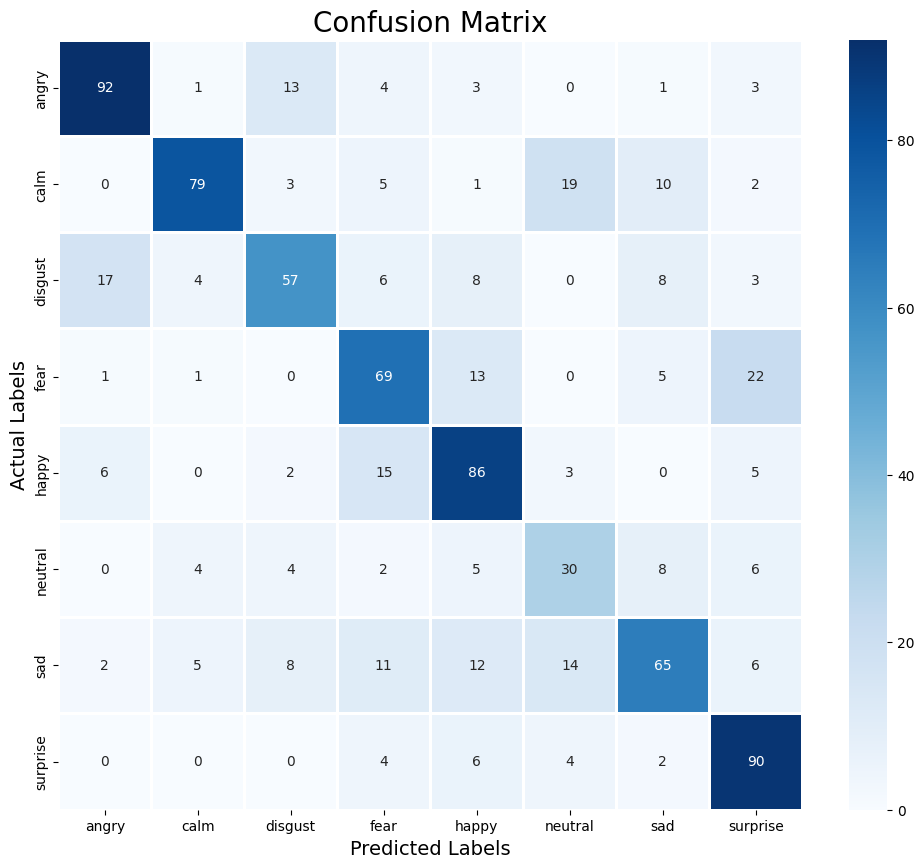

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in encoder.categories_] , columns = [i for i in encoder.categories_])
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.78      0.79      0.78       117
        calm       0.84      0.66      0.74       119
     disgust       0.66      0.55      0.60       103
        fear       0.59      0.62      0.61       111
       happy       0.64      0.74      0.69       117
     neutral       0.43      0.51      0.47        59
         sad       0.66      0.53      0.59       123
    surprise       0.66      0.85      0.74       106

    accuracy                           0.66       855
   macro avg       0.66      0.66      0.65       855
weighted avg       0.67      0.66      0.66       855



In [ ]:
from tensorflow.keras.models import load_model

# Load pre-trained models
lstm_model = load_model('lstm_model.keras')
cnn_model = load_model('ferNet.keras')


/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 13 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, Flatten, TimeDistributed, Conv1D, BatchNormalization, LSTM, Conv2D, MaxPooling2D
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
import cv2
import numpy as np
from tensorflow.keras.layers import Input, Dense, Concatenate, Dropout, Flatten, TimeDistributed, Conv1D, BatchNormalization, LSTM, Conv2D, MaxPooling2D
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

# LSTM model configuration
input_shape = (180, 20, 1,)  # timesteps, features, and channels
lstm_input_shape = (input_shape[0], input_shape[1], input_shape[2])
lstm_input = Input(shape=lstm_input_shape)

# LSTM model layers
x_lstm = TimeDistributed(Conv1D(16, 3, padding='same', activation='relu'))(lstm_input)
x_lstm = TimeDistributed(BatchNormalization())(x_lstm)
x_lstm = TimeDistributed(Flatten())(x_lstm)
x_lstm = LSTM(32)(x_lstm)
x_lstm = Dropout(0.2)(x_lstm)
x_lstm = Dense(32, activation='relu')(x_lstm)
x_lstm = Dropout(0.2)(x_lstm)
lstm_features = x_lstm  # This is the output from the LSTM model

new_size = (32, 32)  # can be Adjusted as needed
x_train_CNN_resized = np.array([cv2.resize(img, new_size) for img in x_train_CNN])

x_train_CNN_processed = x_train_CNN_resized
# CNN model configuration
row, col = x_train_CNN_processed.shape[1], x_train_CNN_processed.shape[2]
cnn_input = Input(shape=(row, col, 1))

# CNN model layers
x_cnn = Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu')(cnn_input)
x_cnn = Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')(x_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = MaxPooling2D(2, 2)(x_cnn)
x_cnn = Dropout(0.25)(x_cnn)
x_cnn = Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(0.01))(x_cnn)
x_cnn = Conv2D(256, kernel_size=(3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01))(x_cnn)
x_cnn = BatchNormalization()(x_cnn)
x_cnn = MaxPooling2D(pool_size=(2, 2))(x_cnn)
x_cnn = Dropout(0.25)(x_cnn)
x_cnn = Flatten()(x_cnn)
x_cnn = Dense(1024, activation='relu')(x_cnn)
x_cnn = Dropout(0.5)(x_cnn)
cnn_features = x_cnn  # This is the output from the CNN model



In [ ]:
# Concatenate LSTM and CNN features
combined_features = Concatenate()([lstm_features, cnn_features])

# Add final dense layers for classification
x = Dense(256, activation='relu')(combined_features)
x = Dropout(0.5)(x)

# Define num_classes (replace 7 with the actual number of classes in your problem)
num_classes = 7
output = Dense(num_classes, activation='softmax')(x)  # Replace num_classes with your number of output classes

# Define the combined model
model = Model(inputs=[lstm_input, cnn_input], outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "functional_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9             │ (None, 48, 48, 1)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 48, 48, 32)     │            320 │ input_layer_9[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 48, 48, 64)     │         18,496 │ conv2d_16[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_13    │ (None, 48, 48, 64)     │            256 │ conv2d_17[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 24, 24, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_25 (Dropout)      │ (None, 24, 24, 64)     │              0 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_8             │ (None, 180, 20, 1)     │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_18 (Conv2D)        │ (None, 24, 24, 128)    │         73,856 │ dropout_25[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_12       │ (None, 180, 20, 16)    │             64 │ input_layer_8[0][0]    │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 22, 22, 256)    │        295,168 │ conv2d_18[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_13       │ (None, 180, 20, 16)    │             64 │ time_distributed_12[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_14    │ (None, 22, 22, 256)    │          1,024 │ conv2d_19[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed_14       │ (None, 180, 320)       │              0 │ time_distributed_13[0… │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_9           │ (None, 11, 11, 256)    │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_4 (LSTM)             │ (None, 32)             │         45,184 │ time_distributed_14[0… │
├──────────────────────

 Total params: 32,428,327 (123.70 MB)

 Trainable params: 32,427,655 (123.70 MB)

 Non-trainable params: 672 (2.62 KB)

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, Concatenate
from tensorflow.keras.models import Model

# Assuming lstm_features and cnn_features are the outputs of LSTM and CNN branches
combined_features = Concatenate()([lstm_features, cnn_features])

# Add Dense layers
x = Dense(256, activation='relu')(combined_features)
x = Dropout(0.5)(x)  # Dropout layer to prevent overfitting
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer
output = Dense(num_classes, activation='softmax')(x)  # For classification


In [ ]:
model = Model(inputs=[lstm_input, cnn_input], outputs=output)

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
